# Song Blob Visualisation
Multi-blob renderer where colour AND layout AND size all come from the embeddings.

In [26]:
import json
import csv
import math
import numpy as np
import colorsys
from PIL import Image
from collections import defaultdict
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

DATA_DIR = "./data"
CSV_DIR  = f"{DATA_DIR}/csv"
EMB_DIR  = f"{DATA_DIR}/embeddings"

with open(f"{EMB_DIR}/genre_embeddings.json") as f: genre_raw = json.load(f)
with open(f"{EMB_DIR}/tag_embeddings.json")   as f: tag_raw   = json.load(f)

genres, tags         = list(genre_raw.keys()), list(tag_raw.keys())
genre2idx, tag2idx   = {g: i for i, g in enumerate(genres)}, {t: i for i, t in enumerate(tags)}

G = np.array(list(genre_raw.values()), dtype=np.float32)
T = np.array(list(tag_raw.values()),   dtype=np.float32)
G_norm = G / (np.linalg.norm(G, axis=1, keepdims=True) + 1e-9)
T_norm = T / (np.linalg.norm(T, axis=1, keepdims=True) + 1e-9)

print(f"genres: {len(genres)} (dim={G.shape[1]}) | tags: {len(tags)} (dim={T.shape[1]})")


genres: 1305 (dim=32) | tags: 985 (dim=64)


In [27]:
# ── Load songs + tags (with popularity preserved) ─────────────────────────
def read_csv(path):
    with open(path, encoding='utf-8', errors='replace') as f:
        reader = csv.reader(f, delimiter=';')
        headers = [h.strip().strip('"') for h in next(reader)[0].split(',')]
        return [dict(zip(headers, [p.strip().strip('"') for p in row]))
                for row in reader if len(row) == len(headers)]

song_lookup = {}
song_genres = defaultdict(set)
for row in read_csv(f"{CSV_DIR}/songs.csv"):
    sid = row['spotify_id']
    song_lookup[sid] = row
    song_genres[sid].add(row['genre_name'])

# keep popularity info for tag blob sizing
song_tags_full = defaultdict(dict)
for row in read_csv(f"{CSV_DIR}/tags.csv"):
    sid, tag = row['song_spotify_id'], row['tag'].lower().strip()
    pop = int(row['popularity']) if row['popularity'].isdigit() else 0
    if pop > song_tags_full[sid].get(tag, 0):
        song_tags_full[sid][tag] = pop

# sorted list of (tag, pop) per song
song_tags = {sid: sorted(d.items(), key=lambda x: -x[1])[:8]
             for sid, d in song_tags_full.items()}

print(f"Loaded {len(song_lookup):,} songs")


Loaded 203,842 songs


In [28]:
# ── PCA: 3-component for colour, 2-component for layout ───────────────────
pca_genre_color = PCA(n_components=3).fit(G_norm)
pca_tag_color   = PCA(n_components=3).fit(T_norm)

# 2D layout PCA — genres + tags share a unified 2D map so they sit in
# semantically meaningful positions relative to each other
shared = np.vstack([G_norm, np.zeros((T_norm.shape[0], G_norm.shape[1]))]) if G_norm.shape[1] != T_norm.shape[1] else np.vstack([G_norm, T_norm])
# can't share PCA across different dim spaces, so fit two
pca_genre_layout = PCA(n_components=2).fit(G_norm)
pca_tag_layout   = PCA(n_components=2).fit(T_norm)

def embedding_to_rgb(vec, pca, temp=3.0, hue_offset=0.15):
    p = np.tanh(pca.transform(vec.reshape(1, -1))[0] * temp)
    h = (np.arctan2(p[1], p[0]) / (2 * np.pi) + 0.5 + hue_offset) % 1.0
    s = np.clip(np.sqrt(p[0]**2 + p[1]**2) * 0.4 + 0.6, 0.65, 1.0)
    v = np.clip((p[2] + 1) / 2 * 0.35 + 0.65, 0.65, 1.0)
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    return np.array([r * 255, g * 255, b * 255], dtype=np.float32)

def embedding_to_xy(vec, pca, size, padding=0.18):
    """Project embedding to (x, y) on canvas. Padding keeps blobs from edges."""
    p   = pca.transform(vec.reshape(1, -1))[0]
    p_t = np.tanh(p * 0.6)  # squash extreme values
    x   = (p_t[0] + 1) / 2 * size * (1 - 2 * padding) + size * padding
    y   = (p_t[1] + 1) / 2 * size * (1 - 2 * padding) + size * padding
    return float(x), float(y)

COLOR_OVERRIDES = {
    "metal":     [150,   0,   0],
    "punk":      [180,  20,  20],
    "grunge":    [100,  60,  20],
    "rap":       [40,   40,  40],
    "hip hop":   [60,   60,  80],
    "folk":      [120, 180,  60],
    "country":   [210, 140,  50],
    "classical": [200, 200, 240],
    "ambient":   [80,  120, 200],
    "blues":     [30,   80, 180],
}
COLOR_OVERRIDES = {k: np.array(v, dtype=np.float32) for k, v in COLOR_OVERRIDES.items()}


In [29]:
# ── Multi-blob renderer (deterministic, embedding-driven) ─────────────────
MIN_BLOBS = 3
MAX_BLOBS = 16

def generate_multi_blob(song, size=600):
    canvas = np.zeros((size, size, 3), dtype=np.float32)
    y_grid, x_grid = np.mgrid[0:size, 0:size]

    blobs = []  # (x, y, radius, color, weight)

    valid_genres = [g for g in song.get('genres', []) if g.lower() in genre2idx or g.lower() in COLOR_OVERRIDES]
    valid_tags   = [(t, p) for t, p in song.get('tags', []) if t.lower() in tag2idx]

    # ── Complexity → blob budget ─────────────────────────────────────────
    raw_complexity = len(valid_genres) + len(valid_tags)
    blob_budget    = int(np.clip(raw_complexity, MIN_BLOBS, MAX_BLOBS))

    # split budget proportionally between genres and tags (roughly)
    if raw_complexity > 0:
        genre_share = max(1, int(round(blob_budget * len(valid_genres) / raw_complexity)))
    else:
        genre_share = 0
    tag_share   = blob_budget - genre_share

    valid_genres = valid_genres[:genre_share]
    valid_tags   = valid_tags[:tag_share]  # already sorted by popularity

    # base sizes scale inversely with how busy the song is
    n_genres = len(valid_genres)
    n_tags   = len(valid_tags)
    genre_base = size * (0.18 + 0.10 / max(n_genres, 1))
    tag_base   = size * (0.10 + 0.06 / max(n_tags, 1))

    # ── Genre blobs ──────────────────────────────────────────────────────
    for genre in valid_genres:
        t = genre.lower()
        if t in COLOR_OVERRIDES:
            color = COLOR_OVERRIDES[t]
        else:
            color = embedding_to_rgb(G_norm[genre2idx[t]], pca_genre_color)

        if t in genre2idx:
            x, y = embedding_to_xy(G_norm[genre2idx[t]], pca_genre_layout, size, padding=0.22)
        else:
            x, y = size // 2, size // 2

        blobs.append((x, y, genre_base, color, 1.0))

    # ── Tag blobs ────────────────────────────────────────────────────────
    max_pop = max((p for _, p in valid_tags), default=1)

    for tag, pop in valid_tags:
        t = tag.lower()
        color = embedding_to_rgb(T_norm[tag2idx[t]], pca_tag_color)
        x, y  = embedding_to_xy(T_norm[tag2idx[t]], pca_tag_layout, size, padding=0.15)
        pop_weight = 0.5 + 0.5 * (pop / max_pop)
        radius     = tag_base * pop_weight
        blobs.append((x, y, radius, color, pop_weight))

    if not blobs:
        return None

    for bx, by, radius, color, weight in blobs:
        dist = np.sqrt((x_grid - bx)**2 + (y_grid - by)**2)
        mask = np.clip(1 - dist / radius, 0, 1) ** 2
        canvas += color[None, None, :] * mask[..., None] * 0.02 * weight

    canvas = np.clip(canvas, 0, 1)
    canvas = np.power(canvas, 0.75)
    return Image.fromarray((np.clip(canvas, 0, 1) * 255).astype(np.uint8))

def blob_from_spotify_id(sid, size=600):
    if sid not in song_lookup: return None, None
    song = {
        'genres': sorted(song_genres.get(sid, [])),
        'tags':   song_tags.get(sid, []),
    }
    return generate_multi_blob(song, size=size), song


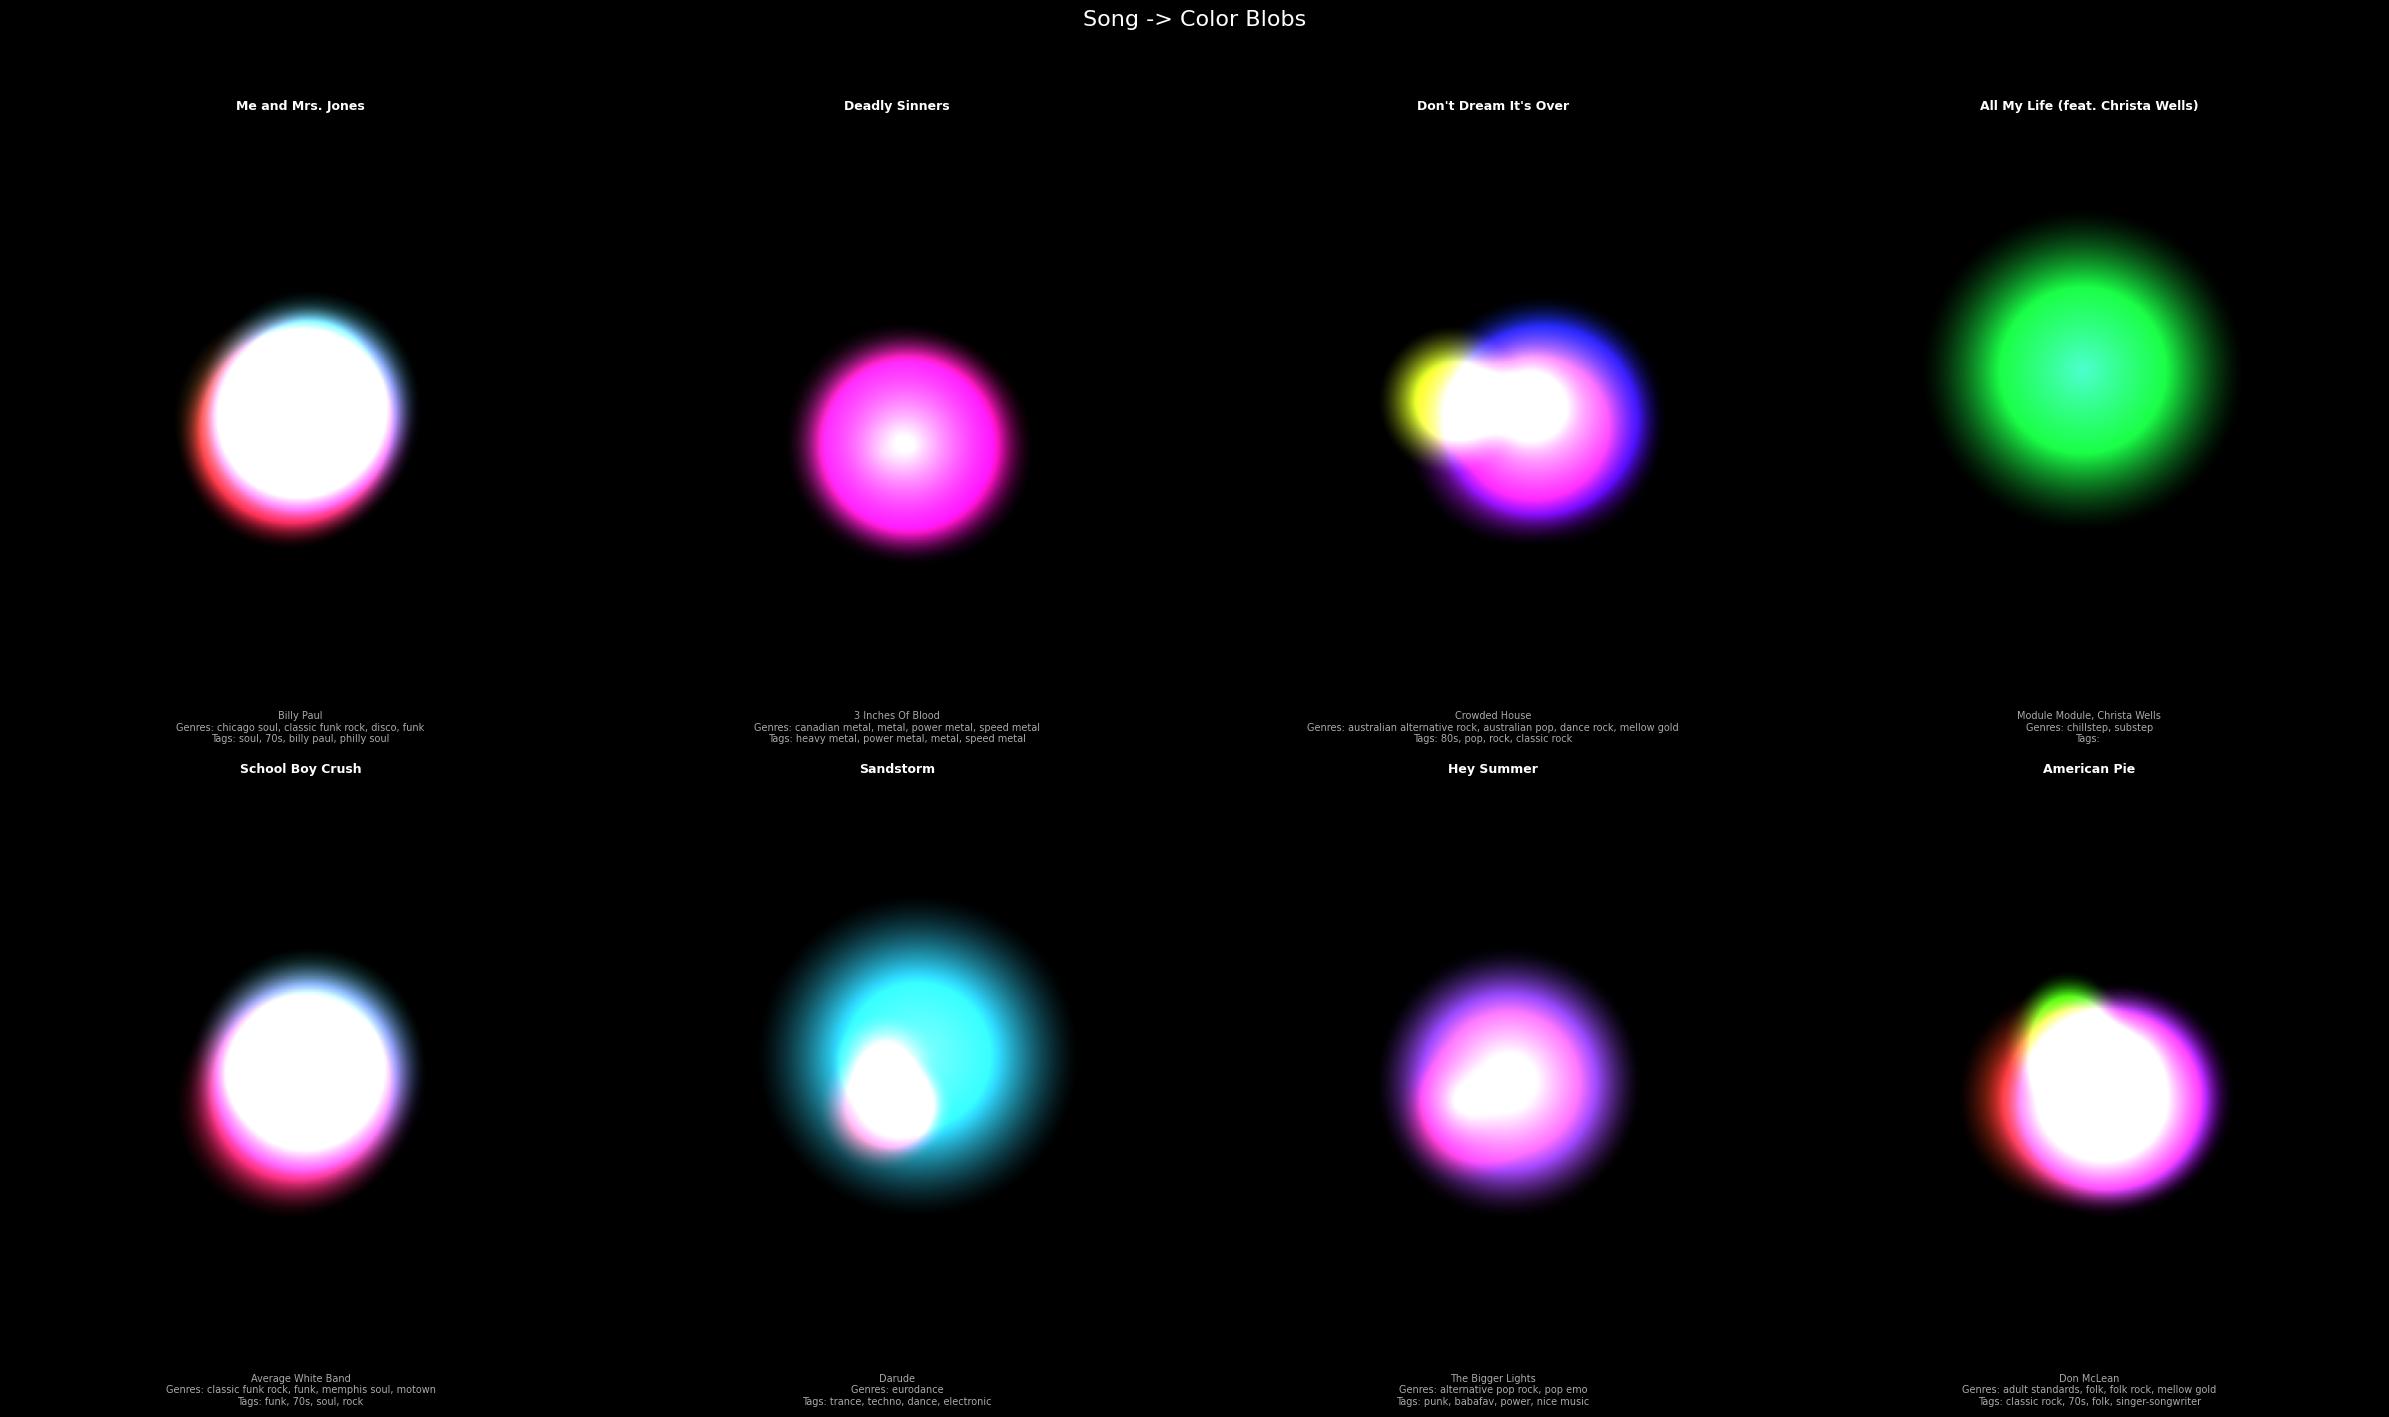

In [30]:
# ── Plot test songs ──────────────────────────────────────────────────────
TEST_IDS = [
    "5GYcaVfaFBHe2gzA6Oybgj",  # Me and Mrs. Jones      - soul blues
    "52mxPsGKbfyElOA0FCtc0l",  # Deadly Sinners         - thrash metal
    "68wIBE5dVVX8RyfZCJnAj5",  # Don't Dream It's Over  - alt rock
    "4YP2nQliU8KsUB74XTP5aP",  # All My Life            - chillstep
    "0wNUTleNAhiAFPghCxLt27",  # School Boy Crush       - funk
    "24CXuh2WNpgeSYUOvz14jk",  # Sandstorm              - eurodance
    "4ygIRtbrrMlL8fBBADwzEj",  # Hey Summer             - pop emo
    "2QgWuCtBpNIpl5trmKCxRf",  # American Pie           - folk rock
]

n_cols = 4
n_rows = math.ceil(len(TEST_IDS) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 7 * n_rows))
fig.patch.set_facecolor('#000000')
axes = axes.flatten()

for i, sid in enumerate(TEST_IDS):
    img, song = blob_from_spotify_id(sid, size=400)
    if img is None:
        axes[i].axis('off')
        continue

    row        = song_lookup.get(sid, {})
    genres_str = ', '.join(song['genres'][:4])
    tags_str   = ', '.join(t for t, _ in song['tags'][:4])

    axes[i].imshow(img)
    axes[i].set_facecolor('#000000')
    axes[i].set_title(row.get('name', sid), color='white', fontsize=9, fontweight='bold', pad=6)
    axes[i].set_xlabel(
        f"{row.get('artist','')}\nGenres: {genres_str}\nTags: {tags_str}",
        color='#aaaaaa', fontsize=7, labelpad=8
    )
    axes[i].set_xticks([]); axes[i].set_yticks([])
    for spine in axes[i].spines.values(): spine.set_visible(False)

for j in range(len(TEST_IDS), len(axes)): axes[j].axis('off')

plt.suptitle("Song -> Color Blobs", fontsize=16, color='white', y=1.01)
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/multi_blobs.png", dpi=150, bbox_inches='tight', facecolor='#000000')
plt.show()
